In [14]:
# no numpy import needed here
try:
    import pandas as pd
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd
try:
    from sklearn.datasets import load_iris
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
df = pd.concat([X, pd.Series(y, name='target')], axis=1)
print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature names:', iris.feature_names)
print('Target names:', iris.target_names.tolist())
# Show a sample of the dataset

df.head()

Features shape: (150, 4)
Target shape: (150,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


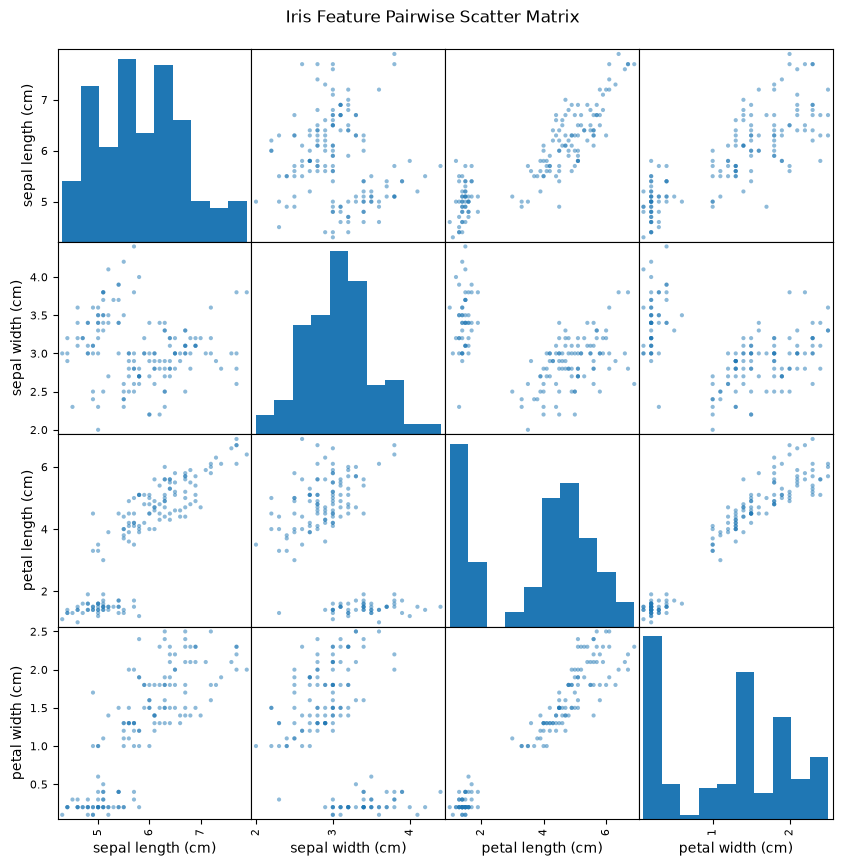

In [22]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
# Reduce text size for readability
pd.options.display.max_columns = None
# Scatter matrix (pairwise scatter plots)
axes = scatter_matrix(X, figsize=(10, 10), diagonal='hist')
# Improve layout
plt.suptitle('Iris Feature Pairwise Scatter Matrix', y=0.92)
plt.show()

RandomForest Test Accuracy: 0.9000

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


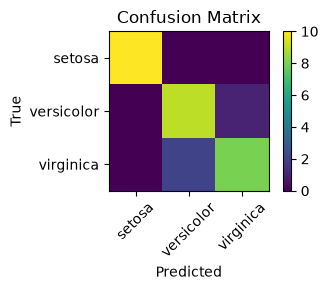

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Train
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
# Predict & evaluate
y_pred = rf_classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'RandomForest Test Accuracy: {acc:.4f}\n')
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))
# Confusion matrix (plot)
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(len(iris.target_names)), iris.target_names, rotation=45)
plt.yticks(range(len(iris.target_names)), iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()
